# CMB Transfer Functions $\Theta_\ell(k)$

Demonstrates the new `Class.get_cmb_transfer()` method, which exposes the line-of-sight transfer function

$$\Theta_\ell(k) \equiv \int d\eta\; S_T(\eta, k)\; j_\ell\!\big(k(\eta_0 - \eta)\big)$$

**before** the convolution with the primordial power spectrum that produces $C_\ell$.

Two views:
1. $\Theta_\ell(k)$ vs $\ell$ for several fixed $k$ — shows acoustic peaks.
2. $\Theta_\ell(k)$ vs $k$ for several fixed $\ell$ — shows the Bessel-windowed source spectrum.
3. Sanity check: $C_\ell^{TT} \approx \int \frac{dk}{k}\, \mathcal{P}_\mathcal{R}(k)\, \Theta_\ell^2(k)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

# Planck 2018 baseline
h_planck = 0.6688
omega_cdm = 0.1206
omega_b = 0.02212
tau_reio = 0.05522
As = 2.092e-9
ns = 0.962
T_cmb = 2.7255 * 1.e6 

## Run CLASS

We need the **transfer module** to run — that requires at least one CMB $C_\ell$ output (`tCl`, `pCl`, `lCl`).

In [2]:
k_out = [1e-4, 1e-3, 1e-2, 1e-1]  # Mpc^-1

precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-8,
    'k_per_decade_primordial': 30.0,
}

settings = {
    'h': h_planck, 'omega_b': omega_b, 'omega_cdm': omega_cdm,
    'A_s': As, 'n_s': ns, 'tau_reio': tau_reio,
    'output': 'tCl,pCl,lCl', 'lensing': 'yes',
    'l_max_scalars': 2500,
    'k_output_values': str(k_out).strip('[]'),
}
settings.update(precision_settings)

lcdm = Class()
lcdm.set(settings)
lcdm.compute()

frac = 1#-1.e-6
common_settings  = {
            'h' : h_planck, 
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'vector_background_mode': 'bianchi',
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'A_s' : As,
            'n_s' : ns,
            'l_max_scalars': 2500, 'k_output_values': str(k_out).strip('[]'),
            'modes' : 's',
            'recombination' : 'RECFAST',
            'output' : 'tCl,pCl,lCl',
            'lensing': 'yes'
            } 
common_settings.update(precision_settings)

In [3]:
mass = 1.e-24
cosmo_angles = {}
angles = [0, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'gamma_Ak' : angles[m]})
    cosmo_angles[m].set({'svt_coupling' : 'no'})
    cosmo_angles[m].set({'vf_mass' : '%s'%mass})
    cosmo_angles[m].compute()

## Native grid: $\Theta_\ell(k)$ on the optimised CLASS $q$-grid

In [4]:
tr = cosmo_angles[0].get_cmb_transfer()  # native grid (k = ptr->k[scalars][:])
print('Available types :', [k for k in tr.keys() if k not in ('l','k')])
print('l grid          :', tr['l'].shape, tr['l'][:5], '...', tr['l'][-3:])
print('k grid (1/Mpc)  :', tr['k'].shape, f"[{tr['k'][0]:.2e}, {tr['k'][-1]:.2e}]")
print('Theta_T shape   :', tr['T'].shape, '  (n_l, n_k)')

Available types : ['T', 'E', 'B', 'phi']
l grid          : (113,) [2 3 4 5 6] ... [2922 2961 3000]
k grid (1/Mpc)  : (2019,) [7.05e-06, 3.81e-01]
Theta_T shape   : (113, 2019)   (n_l, n_k)


## Sanity check: reconstruct $C_\ell^{TT}$

$$ C_\ell^{TT} = 4\pi \int \frac{dk}{k}\, \mathcal{P}_\mathcal{R}(k)\, \Theta_\ell^T(k)^2 $$

with $\mathcal{P}_\mathcal{R}(k) = A_s (k/k_*)^{n_s-1}$ and $k_* = 0.05\,\rm Mpc^{-1}$ (CLASS default pivot).

We compare against `M.raw_cl()` — looped over multipoles (one $C_\ell$ per $\ell$), using the cubic-spline integral that CLASS uses internally..

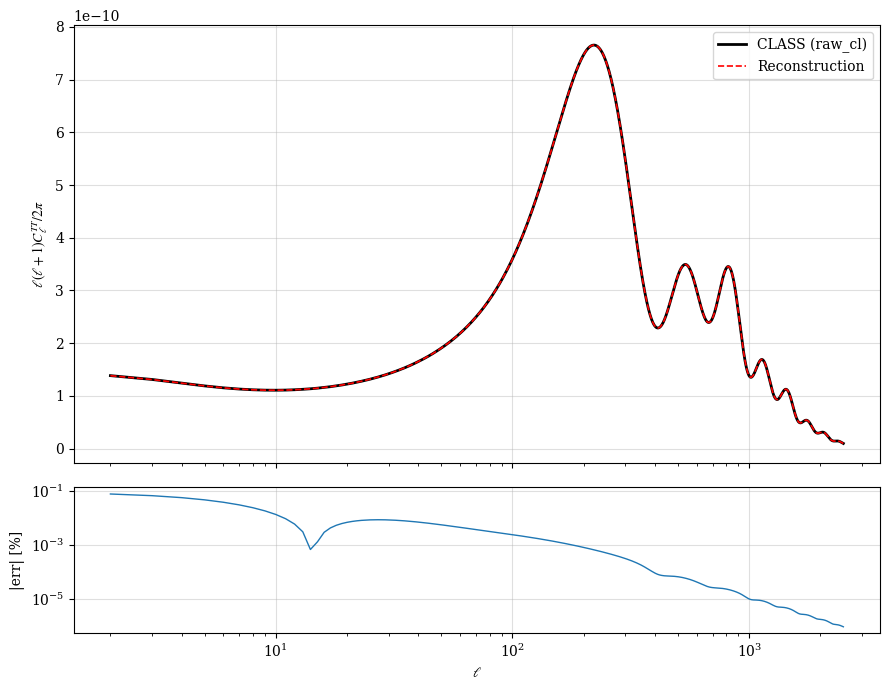

In [5]:
# C_l at EVERY integer l = 2..2500.
# ORDER MATTERS: integrate on the native l grid first (exact), THEN spline C_l in l.
# Splining Theta_l in l first gives ~12% median / 50% max errors — Theta_l(k) is
# not smooth in l at fixed k; only the k-integrated C_l is.
from scipy.interpolate import CubicSpline

tr = cosmo_angles[0].get_cmb_transfer()
k, l_nat, T_nat = tr['k'], tr['l'].astype(int), tr['T']

k_pivot = 0.05
P_R = As * (k / k_pivot)**(ns - 1.0)

Cl_nat = np.array([CubicSpline(k, 4*np.pi*P_R*T_nat[i]**2/k).integrate(k[0], k[-1])
                   for i in range(len(l_nat))])          # exact, on native l

l_full  = np.arange(2, 2501)
Cl_full = CubicSpline(l_nat, Cl_nat)(l_full)             # smooth in l -> safe

Cl_ref = cosmo_angles[0].raw_cl(2500)['tt'][l_full]
fac    = l_full * (l_full + 1) / (2*np.pi)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]})
a1.plot(l_full, fac*Cl_ref,  'k-',  lw=2,   label='CLASS (raw_cl)')
a1.plot(l_full, fac*Cl_full, 'r--', lw=1.2, label=r'Reconstruction')
a1.set(ylabel=r'$\ell(\ell+1)C_\ell^{TT}/2\pi$', xscale='log')
a1.legend(); a1.grid(alpha=0.4)
a2.semilogy(l_full, 100*np.abs(Cl_full/Cl_ref - 1), lw=1)
a2.set(xlabel=r'$\ell$', ylabel='|err| [%]', xscale='log'); a2.grid(alpha=0.4)
plt.tight_layout()
plt.show()